In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

SKEW_FRACTION=0.8
SKEW_PARTITION=0

ROOT = Path("../results/20260430_162503_skew/consumer/consumer-sts-0_metrics/2026-04-19-11-27/")
#ROOT = Path("../results/20260223_052810/consumer/")  
#files = sorted(ROOT.glob("consumer-sts-*_metrics/per_message_latency_run-*_consumer-sts-*.csv"))
files = sorted (ROOT.glob("per_message_latency_2026-04-19-11-27_consumer-sts-0.csv"))

print("Found per-message files:", len(files))
for f in files[:10]:
    print(" -", f.name)

def read_one(fpath: Path) -> pd.DataFrame:
    df = pd.read_csv(fpath)

    # Your per-message schema should include these
    needed = {"recv_ts","producer_ts","e2e_ms","topic","partition","offset","producer_pod","index"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{fpath.name} missing columns: {missing}")

    m = re.search(r"(consumer-sts-\d+)", fpath.name)
    df["consumer_pod"] = m.group(1) if m else "unknown"

    # types
    df["recv_ts"] = pd.to_numeric(df["recv_ts"], errors="coerce")
    df["producer_ts"] = pd.to_numeric(df["producer_ts"], errors="coerce")
    df["e2e_ms"] = pd.to_numeric(df["e2e_ms"], errors="coerce")
    df["partition"] = pd.to_numeric(df["partition"], errors="coerce").astype("Int64")
    df["offset"] = pd.to_numeric(df["offset"], errors="coerce").astype("Int64")

    df = df.dropna(subset=["recv_ts","producer_ts","e2e_ms"])
    return df

lat = pd.concat([read_one(f) for f in files], ignore_index=True)
print("Total sampled messages:", len(lat), "pods:", lat["consumer_pod"].nunique())

lat['e2e_ms'].max()

Found per-message files: 1
 - per_message_latency_2026-04-19-11-27_consumer-sts-0.csv
Total sampled messages: 984 pods: 1


4102.338552474976

In [20]:
pod_summary = (
    lat.groupby("consumer_pod", as_index=False)
       .agg(
           n=("e2e_ms", "size"),
           p50_ms=("e2e_ms", lambda x: float(x.quantile(0.50))),
           p95_ms=("e2e_ms", lambda x: float(x.quantile(0.95))),
           p99_ms=("e2e_ms", lambda x: float(x.quantile(0.99))),  
           max_ms=("e2e_ms", "max"),
       )
       .sort_values("p99_ms", ascending=False)
)

pod_summary


,consumer_pod,n,p50_ms,p95_ms,p99_ms,max_ms
0,consumer-sts-0,984,56.408286,170.912194,1123.536334,4102.338552


In [19]:
s = lat["e2e_ms"].to_numpy()

cluster_summary = {
    "n": len(s),
    "p50_ms": np.quantile(s, 0.50),
    "p95_ms": np.quantile(s, 0.95),
    "p99_ms": np.quantile(s, 0.99),
    #"p999_ms": np.quantile(s, 0.999) if len(arr) >= 1000 else np.nan,
    "max_ms": float(np.max(s)),
}
cluster_summary


{'n': 984,
 'p50_ms': 56.40828609466553,
 'p95_ms': 170.9121942520108,
 'p99_ms': 1123.5363340377592,
 'max_ms': 4102.338552474976}

In [22]:
BUCKET_SEC = 30
t0 = lat["recv_ts"].min()
lat["t_bucket"] = (np.floor((lat["recv_ts"] - t0) / BUCKET_SEC) * BUCKET_SEC).astype(int)

# Tail fractions at multiple thresholds (you can tune these)
thresholds = [500, 700, 800, 900, 1000, 1500]

def bucket_metrics(g):
    arr = g["e2e_ms"].to_numpy()
    out = {
        "n": len(arr),
        "true_p95_ms": np.quantile(arr, 0.95),
        "true_p99_ms": np.quantile(arr, 0.99),
        "true_p999_ms": np.quantile(arr, 0.999) if len(arr) >= 1000 else np.nan,
        "max_ms": float(np.max(arr)),
    }
    for thr in thresholds:
        out[f"tail_frac_gt_{thr}"] = float(np.mean(arr > thr))
    return pd.Series(out)

bucket = (lat.groupby("t_bucket")
          .apply(bucket_metrics)
          .reset_index()
          .sort_values("t_bucket"))

bucket.head()


,t_bucket,n,true_p95_ms,true_p99_ms,true_p999_ms,max_ms,tail_frac_gt_500,tail_frac_gt_700,tail_frac_gt_800,tail_frac_gt_900,tail_frac_gt_1000,tail_frac_gt_1500
0,0,153.0,2285.857153,3714.267139,NaN,4102.338552,0.091503,0.084967,0.071895,0.071895,0.071895,0.065359
1,30,98.0,110.611963,368.681610,NaN,443.085670,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,60,122.0,103.732574,215.784562,NaN,293.735504,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,90,95.0,104.641581,287.158041,NaN,422.691107,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,150,111.0,103.686094,403.942466,NaN,512.628078,0.009009,0.000000,0.000000,0.000000,0.000000,0.000000


In [23]:
from pathlib import Path
path = "../results/20260223_232437_skew/"
run_id = Path(path).resolve().name

print(run_id)

20260223_232437_skew


FileNotFoundError: [Errno 2] No such file or directory: 'analysis_out/20260223_232437_skew/per-message/Per-msg-true p99, max by 30s bucket_20260223_232437_skew.pdf'

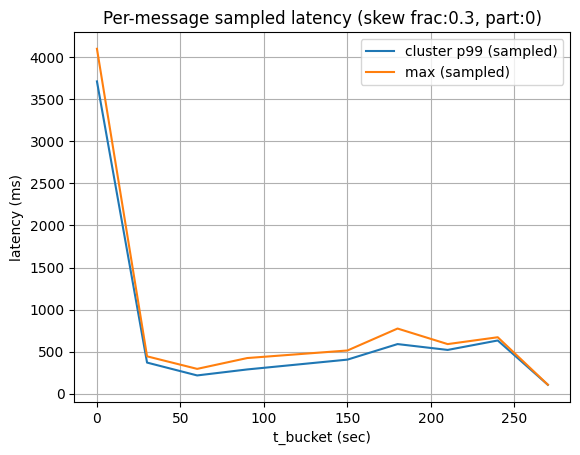

In [24]:
plt.figure()
plt.plot(bucket["t_bucket"], bucket["true_p99_ms"], label="cluster p99 (sampled)")
plt.plot(bucket["t_bucket"], bucket["max_ms"], label="max (sampled)")
plt.xlabel("t_bucket (sec)")
plt.ylabel("latency (ms)")
plt.title(f"Per-message sampled latency (skew frac:0.3, part:0)")
plt.grid(True)
plt.legend()
plt.savefig(f"analysis_out/{run_id}/per-message/Per-msg-true p99, max by 30s bucket_{run_id}.pdf", bbox_inches="tight")
plt.show()

plt.figure()
# for thr in thresholds:
#     plt.plot(bucket["t_bucket"], bucket[f"tail_frac_gt_{thr}"], label=f"P(lat>{thr}ms)")
# plt.xlabel("t_bucket (sec)")
# plt.ylabel("fraction")
# plt.title("Tail fractions by threshold (skew)")
# plt.grid(True)
# plt.legend()
# plt.savefig(f"analysis_out/{run_id}/per-message/Tail fractions by threshold (sampled)_{run_id}.pdf", bbox_inches="tight")
# plt.show()


In [25]:
# Worst buckets by p99 and by max
worst_by_p99 = bucket.sort_values("true_p99_ms", ascending=False).head(10)
worst_by_max = bucket.sort_values("max_ms", ascending=False).head(10)

worst_by_p99, worst_by_max
worst_bucket = int(worst_by_max.iloc[0]["t_bucket"])

tmp = lat[lat["t_bucket"] == worst_bucket].sort_values("e2e_ms", ascending=False).head(30)

tmp[["consumer_pod","e2e_ms","recv_ts","producer_ts","topic","partition","offset","producer_pod","index"]]
tmp.to_csv(f"./analysis_out/{run_id}/per-message/worst_buckets_{run_id}.csv", index=False)


OSError: Cannot save file into a non-existent directory: 'analysis_out/20260223_232437_skew/per-message'

In [26]:
PER_POD_METRICS = "analysis_out/20260223_005626/per_pod_merged_20260223_005626.csv"  
per_pod = pd.read_csv(PER_POD_METRICS)


print(per_pod.columns)

cluster_lag = (per_pod.groupby("t_bucket")
               .agg(window_total=("window_total","sum"),
                    window_viol=("window_viol","sum"),
                    total_lag=("total_lag","sum"),
                    max_lag=("max_lag","max"),
                    lag_skew_ratio=("lag_skew_ratio","max"))
               .reset_index())

merged = bucket.merge(cluster_lag, on="t_bucket", how="left")

merged[["t_bucket","true_p99_ms","max_ms","max_lag","total_lag","lag_skew_ratio"]].head()

cols = ["true_p99_ms","max_ms","max_lag","total_lag","lag_skew_ratio"]
corr = merged[cols].corr(numeric_only=True)
corr


FileNotFoundError: [Errno 2] No such file or directory: 'analysis_out/20260223_005626/per_pod_merged_20260223_005626.csv'

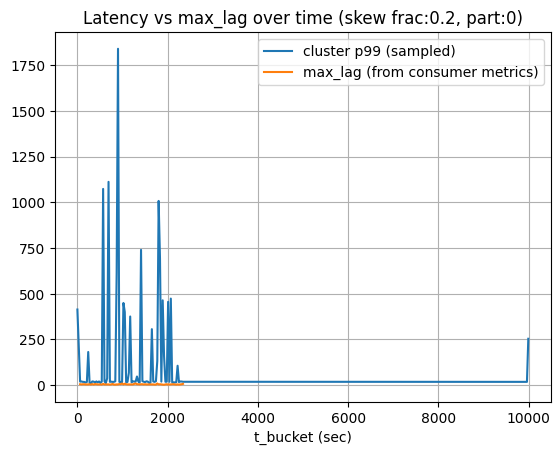

In [83]:
plt.figure()
plt.plot(merged["t_bucket"], merged["true_p99_ms"], label="cluster p99 (sampled)")
plt.plot(merged["t_bucket"], merged["max_lag"], label="max_lag (from consumer metrics)")
plt.xlabel("t_bucket (sec)")
plt.title("Latency vs max_lag over time (skew frac:0.2, part:0)")
plt.grid(True)
plt.legend()
plt.savefig(f"analysis_out/{run_id}/per-message/Latency vs max_lag over time_{run_id}.pdf", bbox_inches="tight")
plt.show()
